In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

In [2]:
df1 = pd.read_csv('Demirjian v. Kohler Data (AI Analyses - for Dr. Siddharth) - Male Data.csv')
df2 = pd.read_csv('Demirjian v. Kohler Data (AI Analyses - for Dr. Siddharth) - Female Data.csv')

In [3]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sl. No.        100 non-null    object 
 1   Sex            100 non-null    object 
 2   Completed Age  100 non-null    int64  
 3   Total          100 non-null    float64
 4   31             100 non-null    int64  
 5   32             100 non-null    int64  
 6   33             100 non-null    int64  
 7   34             100 non-null    int64  
 8   35             100 non-null    int64  
 9   36             100 non-null    int64  
 10  37             100 non-null    int64  
 11  38             100 non-null    int64  
 12  18             100 non-null    int64  
 13  28             100 non-null    int64  
 14  38.1           100 non-null    int64  
 15  48             100 non-null    int64  
dtypes: float64(1), int64(13), object(2)
memory usage: 12.6+ KB


In [5]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sl. No.        202 non-null    object 
 1   Sex            202 non-null    object 
 2   Completed Age  202 non-null    int64  
 3   Total Score    202 non-null    float64
 4   31             202 non-null    int64  
 5   32             202 non-null    int64  
 6   33             202 non-null    int64  
 7   34             202 non-null    int64  
 8   35             202 non-null    int64  
 9   36             202 non-null    int64  
 10  37             202 non-null    int64  
 11  38             202 non-null    int64  
 12  18             202 non-null    int64  
 13  28             201 non-null    float64
 14  38.1           200 non-null    float64
 15  48             200 non-null    float64
dtypes: float64(4), int64(10), object(2)
memory usage: 25.4+ KB


In [6]:
import matplotlib.pyplot as plt

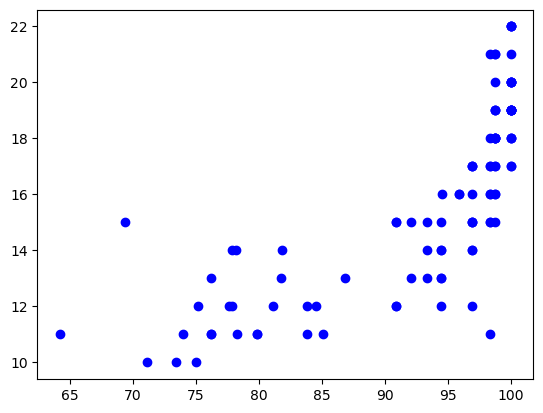

In [ ]:
plt.scatter(df1['Total'],df1['Completed Age'],color = 'blue')
# 

plt.show()

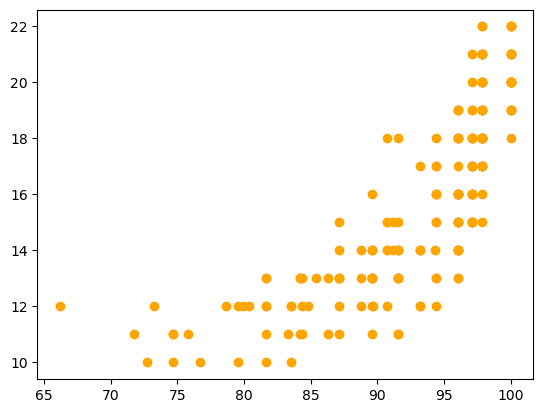

In [10]:
plt.scatter(df2['Total Score'],df2['Completed Age'],color = 'orange')
plt.show()

## So the relation between total score and age is not linear but more like a 2 degree polynomial

In [11]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [29]:
y1 = df1['Completed Age'].dropna()
y2 = df2['Completed Age'].dropna()

In [39]:
X1a = df1[['Total']]
X2a = df2[['Total Score']]
X1b = df1[['31','32','33','34','35','36','37','38']]
X2b = df2[['31','32','33','34','35','36','37','38']]
X1c = df1[['18','28','38','48']]
X2c = df2[['18','28','38','48']]

In [31]:
# X1a.info()
# X1b.info()
# X1c.info()
# X2a.info()
# X2b.info()
X2c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 0 to 201
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   18      200 non-null    int64  
 1   28      200 non-null    float64
 2   38      200 non-null    int64  
 3   48      200 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 7.8 KB


In [32]:
X2c.isna().sum()

18    0
28    0
38    0
48    0
dtype: int64

In [28]:
df2 = df2.dropna(axis=0, how='any')

In [35]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X1b_poly = poly.fit_transform(X1b)
X1c_poly = poly.fit_transform(X1c)
X2b_poly = poly.fit_transform(X2b)
X2c_poly = poly.fit_transform(X2c)

In [40]:
model1 = LinearRegression().fit(X1a, y1)
model2 = LinearRegression().fit(X2a, y2)
model3 = LinearRegression().fit(X1b_poly, y1)
model4 = LinearRegression().fit(X2b_poly, y2)
model5 = LinearRegression().fit(X1c_poly, y1)
model6 = LinearRegression().fit(X2c_poly, y2)

In [43]:
from sklearn.metrics import mean_squared_error
models = [model1,model2,model3,model4,model5,model6]
Xs = [X1a,X2a,X1b_poly,X2b_poly,X1c_poly,X2c_poly]
ys = [y1,y2,y1,y2,y1,y2]
y_preds = []
for i in range(6):
    print("for model",i+1)
    y_preds.append(models[i].predict(Xs[i]))
    print("R² Score:", r2_score(ys[i], y_preds[i]))
    print("Coefficient (slope):", models[i].coef_[0])
    print("Intercept:", models[i].intercept_)
    print("R^2 score:", r2_score(ys[i], y_preds[i]))
    print("MSE:", mean_squared_error(ys[i], y_preds[i]))
    print("-"*20)


for model 1
R² Score: 0.5728129710664007
Coefficient (slope): 0.2733232564858185
Intercept: -9.641841770849116
R^2 score: 0.5728129710664007
MSE: 4.655313366506792
--------------------
for model 2
R² Score: 0.6394372625788209
Coefficient (slope): 0.4010578469353411
Intercept: -21.612770911886038
R^2 score: 0.6394372625788209
MSE: 3.7058548011464425
--------------------
for model 3
R² Score: 0.8033441089963491
Coefficient (slope): 0.038223245438125976
Intercept: 100.67397545793773
R^2 score: 0.8033441089963491
MSE: 2.143077237801385
--------------------
for model 4
R² Score: 0.7838676262548144
Coefficient (slope): -2.7753436211158977e-12
Intercept: 37.83633543764926
R^2 score: 0.7838676262548144
MSE: 2.2214031340436735
--------------------
for model 5
R² Score: 0.7945284238618812
Coefficient (slope): 0.2677668179299847
Intercept: 9.79810010218494
R^2 score: 0.7945284238618812
MSE: 2.239147048122764
--------------------
for model 6
R² Score: 0.7513743634052936
Coefficient (slope): -0.301

## Now testing on actual test dataset

In [85]:

df4 = pd.read_csv("Demirjian v. Kohler Data (AI Analyses - for Dr. Siddharth) - Female Test Data.csv")
df3 = pd.read_csv("Demirjian v. Kohler Data (AI Analyses - for Dr. Siddharth) - Male Test Data.csv")

In [86]:
df3.dropna(inplace = True)
df4.dropna(inplace = True)

In [102]:
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

y3 = df3['Completed Age']   # male test
y4 = df4['Completed Age']   # female test

X3a = df3[['Total']]
X4a = df4[['Total Score']]

X3b = df3[['31','32','33','34','35','36','37','38']]
X4b = df4[['31','32','33','34','35','36','37','38']]

X3c = df3[['18','28','38','48']]
X4c = df4[['18','28','38','48']]

X3b_poly = poly.fit_transform(X3b)
X3c_poly = poly.fit_transform(X3c)
X4b_poly = poly.fit_transform(X4b)
X4c_poly = poly.fit_transform(X4c)
OGtestXs = [X3a, X4a, X3b, X4b, X3c, X4c]
testXs = [X3a, X4a, X3b_poly, X4b_poly, X3c_poly, X4c_poly]
testys = [y3, y4, y3, y4, y3, y4]

models = [model1, model2, model3, model4, model5, model6]

for i in range(6):
    print("For model", i+1)
    
    preds = models[i].predict(testXs[i])  # predictions
    true_y = testys[i]
    
    print("R^2 score:", r2_score(true_y, preds))
    print("MSE:", mean_squared_error(true_y, preds))
    
    print("-"*30)


For model 1
R^2 score: 0.7068207746303914
MSE: 2.192772431166777
------------------------------
For model 2
R^2 score: 0.6135846146037569
MSE: 2.884343354525367
------------------------------
For model 3
R^2 score: 0.8776043937877608
MSE: 0.9154322263447949
------------------------------
For model 4
R^2 score: 0.6299329842487049
MSE: 2.7623132461890325
------------------------------
For model 5
R^2 score: 0.6888145284894998
MSE: 2.3274463668004275
------------------------------
For model 6
R^2 score: 0.6096833816610346
MSE: 2.91346355971921
------------------------------


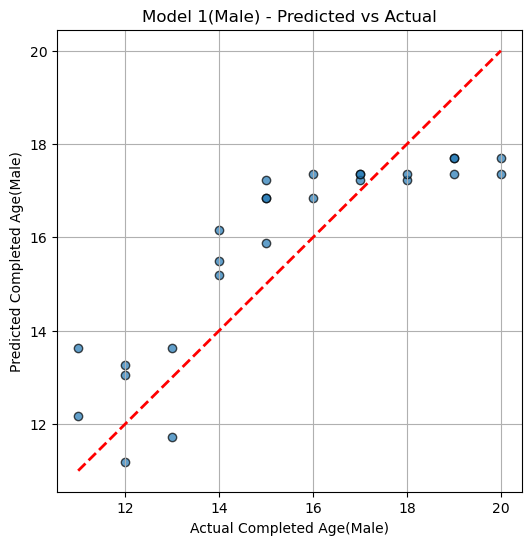

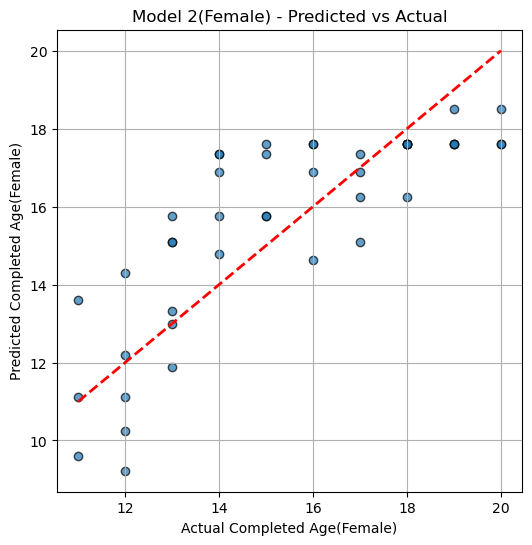

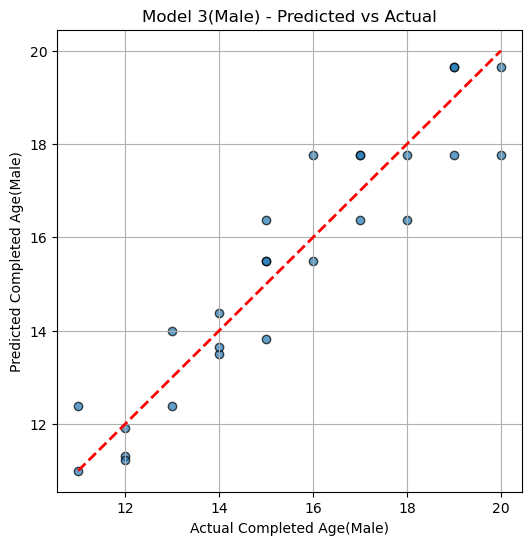

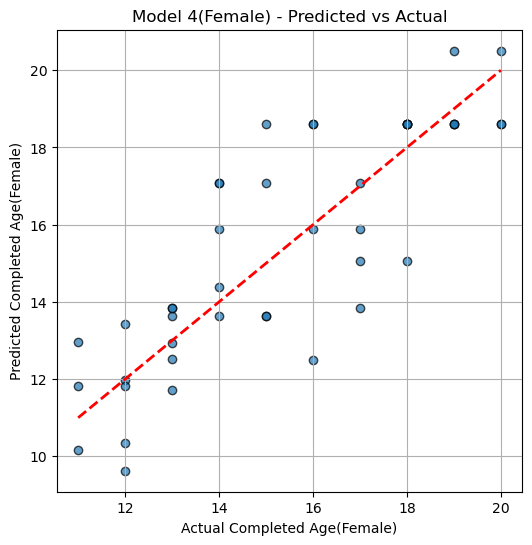

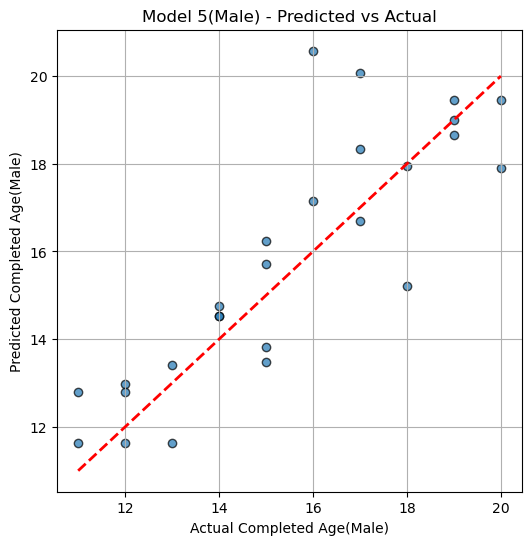

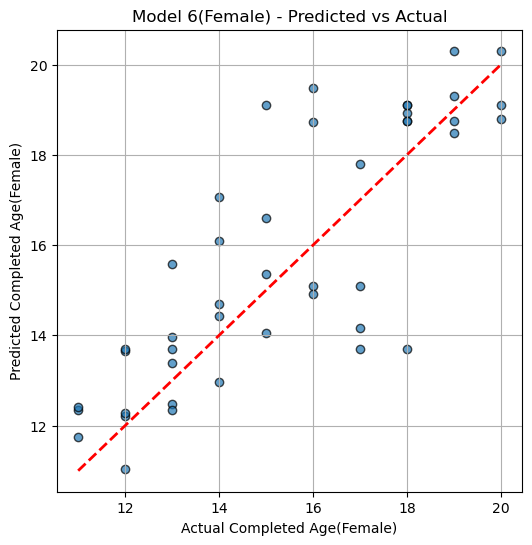

In [94]:
import matplotlib.pyplot as plt

for i in range(6):
    preds = models[i].predict(testXs[i])
    true_y = testys[i]
    plt.figure(figsize=(6, 6))
    plt.scatter(true_y, preds, alpha=0.7, edgecolor="k")
    plt.plot([true_y.min(), true_y.max()],
             [true_y.min(), true_y.max()],
             'r--', lw=2)  # ideal line (y=x)
    if i in [0,2,4]:
        plt.xlabel("Actual Completed Age(Male)")
        plt.ylabel("Predicted Completed Age(Male)")
        plt.title(f"Model {i+1}(Male) - Predicted vs Actual")
    else:
        plt.xlabel("Actual Completed Age(Female)")
        plt.ylabel("Predicted Completed Age(Female)")
        plt.title(f"Model {i+1}(Female) - Predicted vs Actual")

    plt.grid(True)
    plt.show()


## Observations:
1. Models trained on male data are more accurate cause male data has more entries as compared to female data whereas female data faces overfitting
2. Models trained on second set of features were the most accurate (R^2 near to 1 & MSE is comparatively less)